In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tabulate import tabulate

In [2]:
DIMENSION = '1M'

In [ ]:
DATASET = f'../../datasets/paysim/paysim_old/{DIMENSION}/rawLog.csv'

In [102]:
import csv

# Open the CSV file
with open(DATASET, mode='r', newline='') as infile:
    reader = csv.DictReader(infile)
    rows = list(reader)

In [4]:
chunk_acc = pd.read_csv(DATASET, chunksize=10000)
df = pd.concat(chunk_acc)

In [6]:
# Initialize balances dictionary
balances = {}

# Modify the rows
# for row in rows:
for idx, row in df.iterrows():
    try:
        orig = row['nameOrig']
        dest = row['nameDest']
        amount = float(row['amount'])
        action = row['action']

        # Use the last known balance or fallback to the CSV value
        old_balance_orig = balances.get(orig, float(row['oldBalanceOrig']))
        old_balance_dest = balances.get(dest, float(row['oldBalanceDest']))

        if action == 'CASH_IN':
            # dest gains money
            new_balance_dest = old_balance_dest - amount
            balances[dest] = new_balance_dest  # Update the live balance
            row['newBalanceDest'] = round(new_balance_dest, 2)
            row['oldBalanceDest'] = round(old_balance_dest, 2)  # also important to update oldBalanceDest!
        
        elif action == 'CASH_OUT' or action == 'DEBIT':
            # orig loses money
            new_balance_dest = old_balance_dest + amount
            balances[dest] = new_balance_dest
            row['newBalanceDest'] = round(new_balance_dest, 2)
            row['oldBalanceDest'] = round(old_balance_dest, 2)  #  also important to update oldBalanceOrig!            

    except ValueError:
        # Handle invalid values if needed
        row['newBalanceDest'] = ''
        row['newBalanceOrig'] = ''


In [9]:
# Initialize balances dictionary
balances = {}

# Modify the rows properly
for idx, row in df.iterrows():
    try:
        orig = row['nameOrig']
        dest = row['nameDest']
        amount = float(row['amount'])
        action = row['action']

        # Use the last known balance or fallback to the CSV value
        old_balance_orig = balances.get(orig, float(row['oldBalanceOrig']))
        old_balance_dest = balances.get(dest, float(row['oldBalanceDest']))

        if action == 'CASH_IN':
            # dest gains money
            new_balance_dest = old_balance_dest - amount
            balances[dest] = new_balance_dest

            df.at[idx, 'newBalanceDest'] = round(new_balance_dest, 2)
            df.at[idx, 'oldBalanceDest'] = round(old_balance_dest, 2)

        elif action == 'CASH_OUT' or action == 'DEBIT':
            # orig loses money
            new_balance_dest = old_balance_dest + amount
            balances[dest] = new_balance_dest

            df.at[idx, 'newBalanceDest'] = round(new_balance_dest, 2)
            df.at[idx, 'oldBalanceDest'] = round(old_balance_dest, 2)

    except ValueError:
        df.at[idx, 'newBalanceDest'] = ''
        df.at[idx, 'newBalanceOrig'] = ''


In [10]:
# Save to new CSV
NEW_DATASET = f"paysim{DIMENSION}.csv"
df.to_csv(NEW_DATASET, index=False)

In [8]:
import csv

# Write back to a new CSV file (or overwrite the original)
NEW_DATASET = F"paysim{DIMENSION}.csv"
with open(NEW_DATASET, mode='w', newline='') as outfile:
    writer = csv.DictWriter(outfile, fieldnames=reader.fieldnames)
    writer.writeheader()
    for row in rows:
        writer.writerow(row)

NameError: name 'reader' is not defined

# Explore csv

In [33]:
#DIMENSION = '100'
#DATASET = f'../../datasets/paysim/{DIMENSION} user/rawLog.csv'

DATASET = 'paysim100-modified.csv'

df = pd.read_csv(DATASET)
# df = df.iloc[:500000]
df

,step,action,amount,nameOrig,oldBalanceOrig,newBalanceOrig,nameDest,oldBalanceDest,newBalanceDest,isFraud,isFlaggedFraud,isUnauthorizedOverdraft
0,1,CASH_IN,92873.72,C1000631618,14255.88,107129.61,M7146327871,0.00,-92873.72,0,0,0
1,1,CASH_IN,131508.47,C9621947975,96.24,131604.72,M3557595485,0.00,-131508.47,0,0,0
2,1,CASH_IN,80352.42,C9301748160,84.13,80436.55,M6783489252,0.00,-80352.42,0,0,0
3,1,CASH_IN,223733.58,C6065783459,62.17,223795.75,M6783489252,-80352.42,-304086.00,0,0,0
4,1,CASH_IN,111459.32,C7256905148,45.61,111504.94,M6498566449,0.00,-111459.32,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
12487,361,CASH_OUT,102820.66,C4910674511,2999379.89,2896559.23,M6498566449,-43093028.09,-42990207.43,0,0,0
12488,361,PAYMENT,13940.70,C1105021101,2949359.98,2935419.28,M7146327871,1990739.78,2004680.48,0,0,0
12489,361,CASH_IN,157853.18,C1105021101,2935419.28,3093272.47,M1177335412,-33442601.37,-33600454.55,0,0,0
12490,361,TRANSFER,453000.13,C4061895188,2025979.17,1572979.04,C0867198867,5140598.80,5593598.93,0,0,0


In [34]:
prefixes1 = df['nameOrig'].str[0].unique()
prefixes2 = df['nameDest'].str[0].unique()

print(prefixes1, prefixes2)

df['action'].unique()

['C'] ['M' 'C' 'B']


array(['CASH_IN', 'PAYMENT', 'TRANSFER', 'CASH_OUT', 'DEBIT'],
      dtype=object)

In [35]:
df['isFraud'].unique()

array([0, 1])

In [36]:
balances = {}
fraud = 0

for _, row in df.iterrows():
    is_fraud = row['isFraud']
    orig = row['nameOrig']
    dest = row['nameDest']
    oldorig = row['oldBalanceOrig']
    olddest = row['oldBalanceDest']
    neworig = row['newBalanceOrig']
    newdest = row['newBalanceDest']

    # Track origin account
    if row['nameOrig'] not in balances:
        balances[row['nameOrig']] = {}
    balances[row['nameOrig']][row['step']] = row['newBalanceOrig']

    # if orig == 'M7146327871':
    #     print(f"step : {row['step']}")
    #     print(f"amount: {row['amount']}")
    #     print(f"old orig: {oldorig}")
    #     print(f"new orig: {neworig}")
    # if dest == 'M7146327871':
    #     print(f"step : {row['step']}")
    #     print(f"amount: {row['amount']}")
    #     print(f"old dest: {olddest}")
    #     print(f"new dest: {newdest}")

    # Track destination account
    if row['nameDest'] not in balances:
        balances[row['nameDest']] = {}
    balances[row['nameDest']][row['step']] = row['newBalanceDest']

    if is_fraud:
        fraud += 1

In [37]:
print(f"Total fraudolent transactions: {fraud} out of {len(df)} transactions")
fraud_perc = fraud / len(df)
print(f"Anomaly percentage: {round(fraud_perc * 100, 2)}")

Total fraudolent transactions: 18 out of 12492 transactions
Anomaly percentage: 0.14


In [38]:
print(f"Number of users: {len(balances)}")

Number of users: 111


In [39]:
# Create DataFrame
balance_df = pd.DataFrame.from_dict(balances, orient='index').T

# Identify the full range of steps (days)
full_range = range(balance_df.index.min(), balance_df.index.max() + 1)

# Reindex to include all steps, then forward fill
balance_df = balance_df.reindex(full_range).fillna(method='ffill').fillna(method='bfill')

/var/folders/s6/4jprwbqj4012tkll2ww6r5hr0000gq/T/ipykernel_4456/707783276.py:8: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  balance_df = balance_df.reindex(full_range).fillna(method='ffill').fillna(method='bfill')


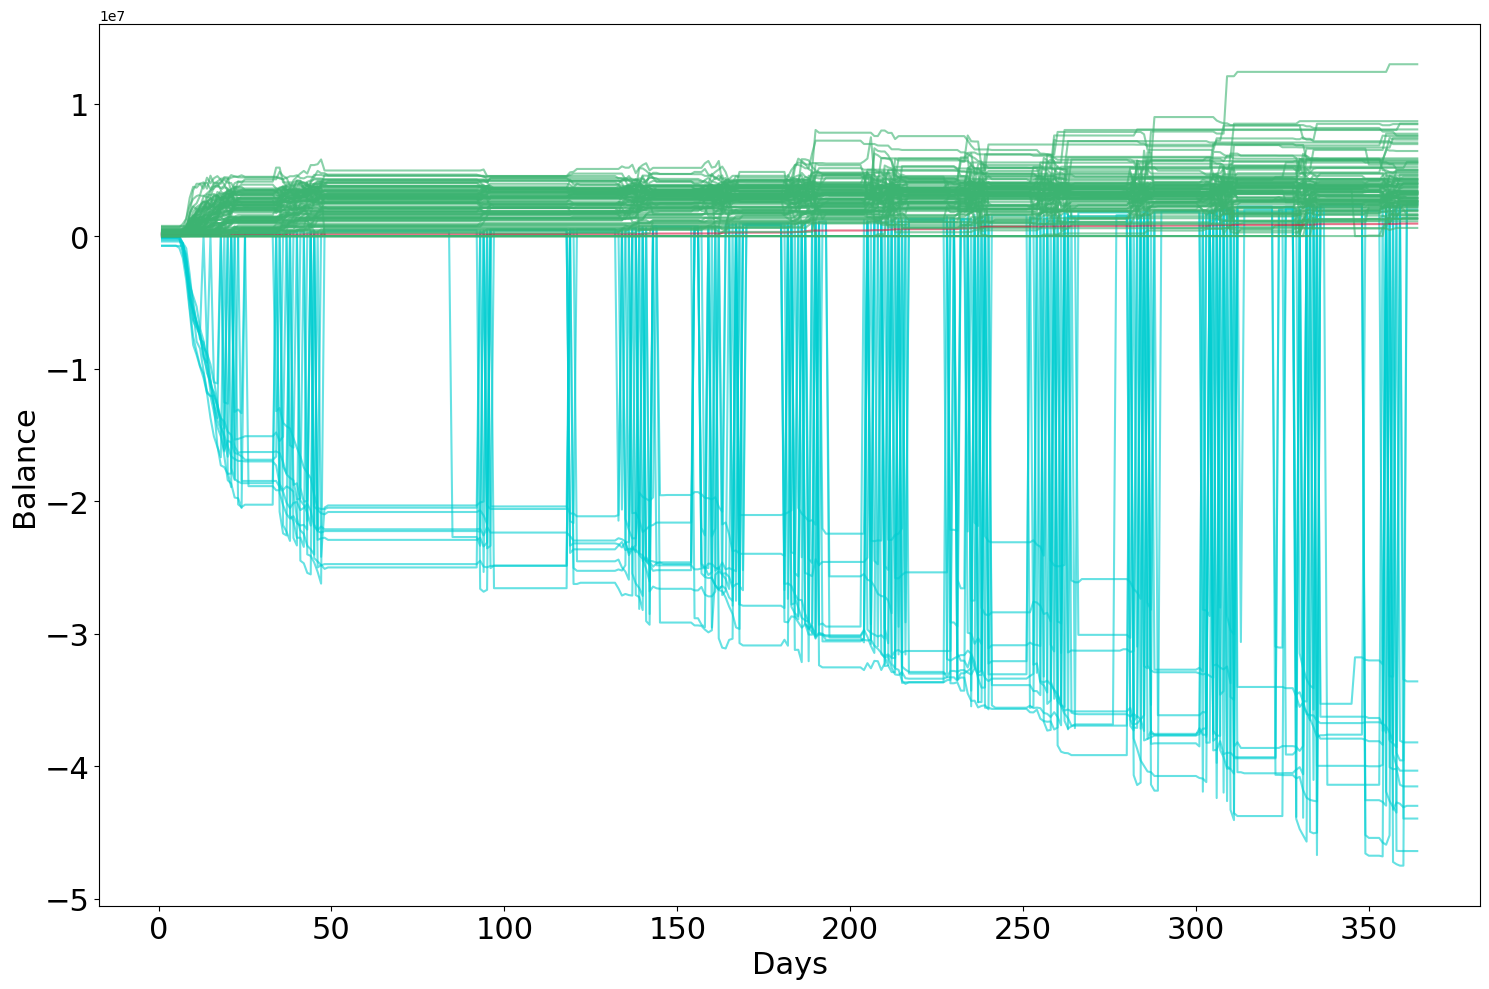

In [40]:
# Plot the balance evolution for all users (columns) as separate lines
# plt.figure(figsize=(15,10), dpi= 300)
plt.figure(figsize=(15,10))

# Plot each column (account balance) as a line
for user in balance_df.columns:
    if user.startswith('C'):
        color = 'mediumseagreen'
    elif user.startswith('B'):
        color = 'crimson'
    else:
        color = 'darkturquoise'
    plt.plot(balance_df.index, balance_df[user], color=color, label=f"User {user}", alpha=0.6)

# Add title and labels
plt.xlabel("Days", fontsize=22)
plt.ylabel("Balance", fontsize=22)

# Rotate x-axis labels for better visibility
plt.tick_params(axis='x', labelsize=22)
plt.tick_params(axis='y', labelsize=22)

# Display the plot
plt.tight_layout()
plt.show()

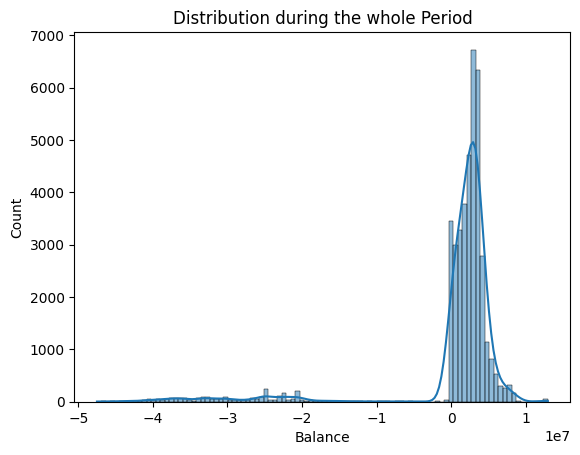

In [41]:
values_df = balance_df.values.flatten()
# Plot distribution for all the days (aggregated over users and days)
sns.histplot(values_df, bins=100, kde=True)
plt.title("Distribution during the whole Period")
plt.xlabel("Balance")
plt.show()

In [42]:
balance_df.T

,1,2,3,4,5,6,7,8,9,10,...,355,356,357,358,359,360,361,362,363,364
C1000631618,107129.61,107129.61,107129.61,107129.61,107129.61,107129.61,107129.61,107129.61,512481.76,799405.17,...,3081104.69,2932202.19,2885341.03,2930984.21,2930984.21,2718063.80,2718063.80,2718063.80,2718063.80,2718063.80
M7146327871,-410471.41,-410471.41,-410471.41,-410471.41,-410471.41,-410471.41,-523995.08,-1965823.16,-4294610.75,-5596101.31,...,1892360.99,-37983882.22,1954961.06,-38995670.40,-39562016.50,-39559750.20,2004680.48,2004680.48,2004680.48,2004680.48
C9621947975,131604.72,131604.72,131604.72,131604.72,131604.72,131604.72,131604.72,373754.15,731821.37,731821.37,...,3478059.72,3501554.13,3501554.13,3485069.81,3485069.81,3485069.81,3485069.81,3485069.81,3485069.81,3485069.81
M3557595485,-131508.47,-131508.47,-131508.47,-131508.47,-131508.47,-131508.47,-1227273.61,-2765561.18,-4208757.73,-6465680.02,...,2280567.87,-40076367.90,-40231496.45,-40189831.37,-41404070.97,-41523728.91,-41523728.91,-41523728.91,-41523728.91,-41523728.91
C9301748160,80436.55,80436.55,80436.55,80436.55,80436.55,80436.55,99156.55,885095.87,885095.87,1050918.58,...,4574234.06,4554881.98,4434499.10,4434499.10,4123403.32,4094414.49,4094414.49,4094414.49,4094414.49,4094414.49
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CC1010384077,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,4313174.86,4313174.86,4313174.86,4313174.86,4313174.86,4313174.86,4313174.86,4313174.86,4313174.86,4313174.86
CC8841157157,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,2249334.87,2249334.87,2249334.87,2249334.87,2753311.34,2753311.34,2753311.34,2753311.34,2753311.34,2753311.34
CC0584867436,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,1285822.98,1285822.98,1285822.98,1285822.98,1285822.98,1285822.98,1285822.98,1285822.98,1285822.98,1285822.98
CC3222417434,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,1567009.00,1567009.00,1567009.00,1567009.00,1567009.00,1567009.00,1567009.00,1567009.00,1567009.00,1567009.00


# SQUIC

In [43]:
df = balance_df

In [44]:
ROWS = len(df.iloc[0])
ROWS

111

## Normalization

In [45]:
Y = df.T.to_numpy()  # Transpose to get shape (users, days)
#l = [1e5, 3e5, 5e5, 7e5, 9e5, 11e5, 13e5, 15e5, 17e5, 19e5]

l = [9e-1, 5e-1, 2e-1, 1e-1, 9e-2, 5e-2, 2e-2, 1e-2]

In [46]:
print(np.isnan(Y).sum())  # should be 0 (no NaN)
print(np.linalg.matrix_rank(Y))  # should be full rank (ideally)
print(np.linalg.cond(Y))  # condition number; high = bad

0
111
28952.331488673786


In [47]:
from SQUIC_functions import *

In [48]:
squic_dict = {}

In [49]:
Y = df.T.to_numpy()
# normalize the Y input data to achieve unit variance
Y_new = np.diag(1/np.std(Y,1)) @ Y # each row of Y is scaled by the inverse of its standard deviation
# normalizes each row so that the std dev of each user's balance over the days becomes 1

# Y_new has shape (Users × Days).
# S will have shape (Users × Users).

# double check if this is correct by 
S = np.cov(Y_new, bias=True) # "bias=true" you force cove to use n samples instead of n-1

In [50]:
print("NaNs?", np.isnan(Y_new).any())
print("Infs?", np.isinf(Y_new).any())
print("Max:", np.max(Y_new))
print("Min:", np.min(Y_new))
print("Mean std per row (should be 1):", round(np.mean(np.std(Y_new, axis=1)), 2))

NaNs? False
Infs? False
Max: 8.543118154566585
Min: -3.2812663195723086
Mean std per row (should be 1): 0.9999999999999999


In [51]:
stds = np.std(Y, axis=1)
safe_stds = np.clip(stds, 1e-8, None)  # don't allow std < 1e-8
Y_new = np.diag(1 / safe_stds) @ Y

print("NaNs?", np.isnan(Y_new).any())
print("Infs?", np.isinf(Y_new).any())
print("Max:", np.max(Y_new))
print("Min:", np.min(Y_new))
print("Mean std per row (should be 1):", round(np.mean(np.std(Y_new, axis=1)), 2))

NaNs? False
Infs? False
Max: 8.543118154566585
Min: -3.2812663195723086
Mean std per row (should be 1): 0.9999999999999999


In [52]:
print(np.linalg.cond(Y_new))  # condition number; high = bad

3987.8383522503664


In [53]:
l

[0.9, 0.5, 0.2, 0.1, 0.09, 0.05, 0.02, 0.01]

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           111 x 364 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.000000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=4.43e-04 nnz(S)/p=3.49e+00
* iter=1 time=8.37e-04 obj=1.82e+02 |delta(obj)|/obj=3.92e-01 nnz(X,L,W)/p=[3.49e+00 2.44e+00 1.63e+00] lns_iter=2 
* iter=2 time=1.32e-03 obj=1.82e+02 |delta(obj)|/obj=7.05e-05 nnz(X,L,W)/p=[3.49e+00 2.44e+00 5.04e+00] lns_iter=1 
#SQUIC Finished: time=2.87e-03 nnz(X,W)/p=[3.49e+00

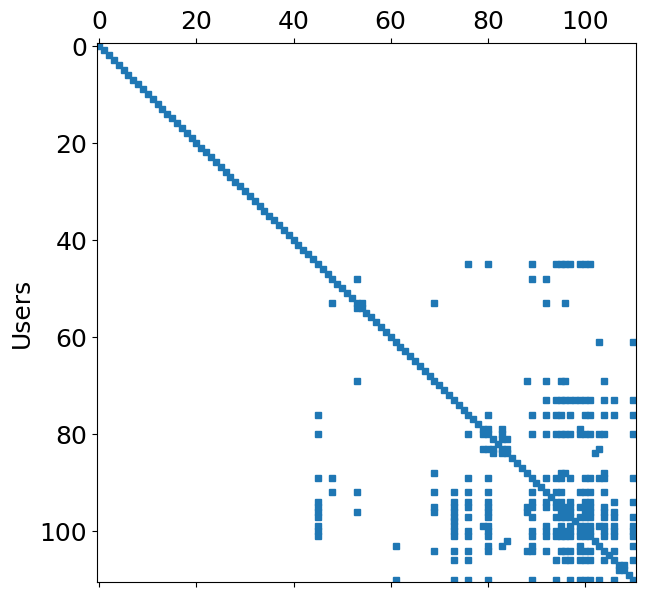

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           111 x 364 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      5.000000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=5.10e-04 nnz(S)/p=3.16e+01
* iter=1 time=1.85e-03 obj=1.55e+02 |delta(obj)|/obj=2.83e-01 nnz(X,L,W)/p=[3.16e+01 3.13e+01 1.90e+00] lns_iter=5 
* iter=2 time=5.66e-03 obj=1.54e+02 |delta(obj)|/obj=5.25e-03 nnz(X,L,W)/p=[3.16e+01 3.13e+01 6.59e+01] lns_iter=6 
* iter=3 time=2.84e-02 obj=1.48e+02 |delta(obj)|/ob

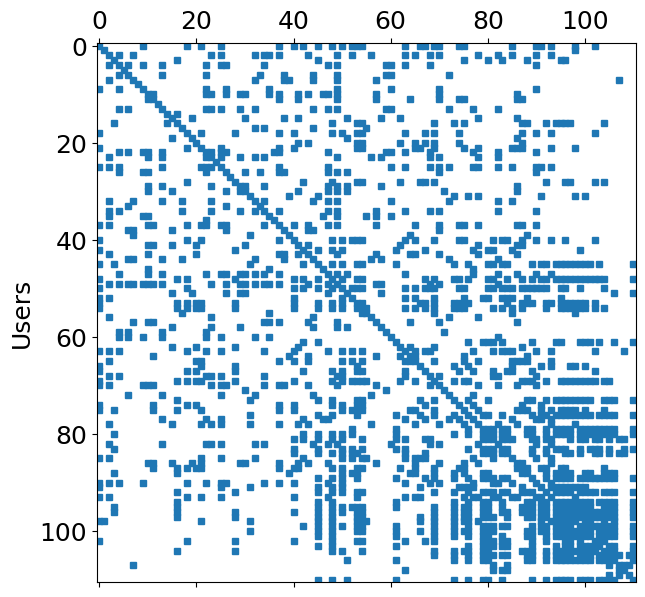

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           111 x 364 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      2.000000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=5.69e-04 nnz(S)/p=7.53e+01
* iter=1 time=2.77e-03 obj=1.03e+02 |delta(obj)|/obj=7.36e-02 nnz(X,L,W)/p=[7.53e+01 5.28e+01 1.40e+01] lns_iter=6 
* iter=2 time=5.81e-03 obj=9.97e+01 |delta(obj)|/obj=3.74e-02 nnz(X,L,W)/p=[7.53e+01 5.28e+01 1.10e+02] lns_iter=7 
* iter=3 time=2.69e-02 obj=9.36e+01 |delta(obj)|/ob

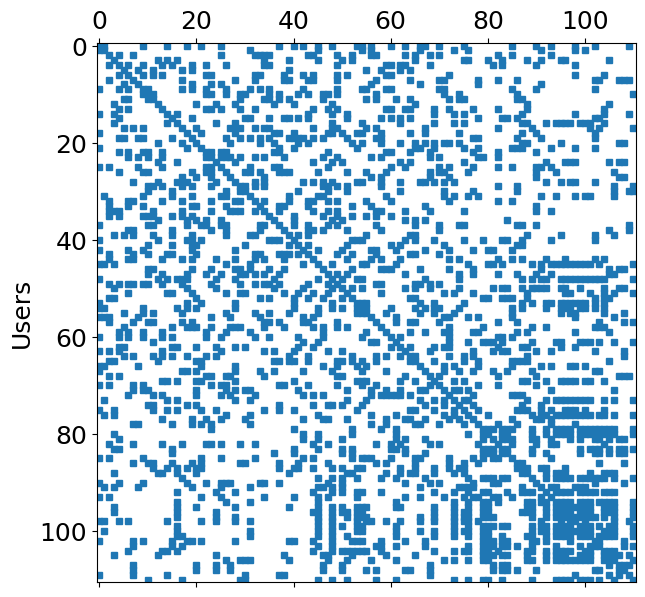

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           111 x 364 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=5.73e-04 nnz(S)/p=9.24e+01
* iter=1 time=2.87e-03 obj=9.82e+01 |delta(obj)|/obj=1.31e-01 nnz(X,L,W)/p=[9.24e+01 5.55e+01 1.00e+00] lns_iter=7 
* iter=2 time=4.81e-03 obj=8.70e+01 |delta(obj)|/obj=1.29e-01 nnz(X,L,W)/p=[9.24e+01 5.55e+01 1.08e+02] lns_iter=8 
* iter=3 time=3.42e-02 obj=7.57e+01 |delta(obj)|/ob

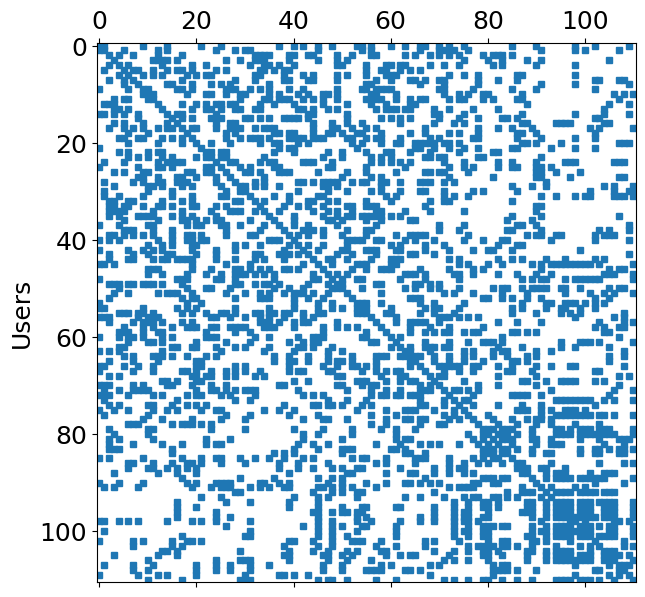

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           111 x 364 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.000000e-02 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=6.70e-04 nnz(S)/p=9.42e+01
* iter=1 time=2.85e-03 obj=9.60e+01 |delta(obj)|/obj=1.56e-01 nnz(X,L,W)/p=[9.42e+01 5.55e+01 1.00e+00] lns_iter=7 
* iter=2 time=5.23e-03 obj=8.44e+01 |delta(obj)|/obj=1.38e-01 nnz(X,L,W)/p=[9.42e+01 5.55e+01 1.07e+02] lns_iter=8 
* iter=3 time=5.42e-02 obj=7.28e+01 |delta(obj)|/ob

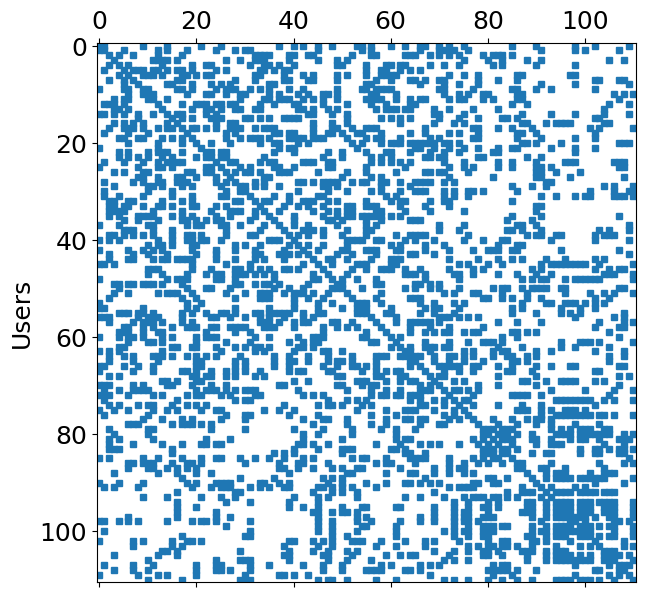

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           111 x 364 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      5.000000e-02 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=7.52e-04 nnz(S)/p=1.02e+02
* iter=1 time=2.75e-03 obj=8.72e+01 |delta(obj)|/obj=2.73e-01 nnz(X,L,W)/p=[1.02e+02 5.55e+01 1.00e+00] lns_iter=7 
* iter=2 time=5.24e-03 obj=7.38e+01 |delta(obj)|/obj=1.81e-01 nnz(X,L,W)/p=[1.02e+02 5.55e+01 1.08e+02] lns_iter=8 
* iter=3 time=4.20e-02 obj=6.13e+01 |delta(obj)|/ob

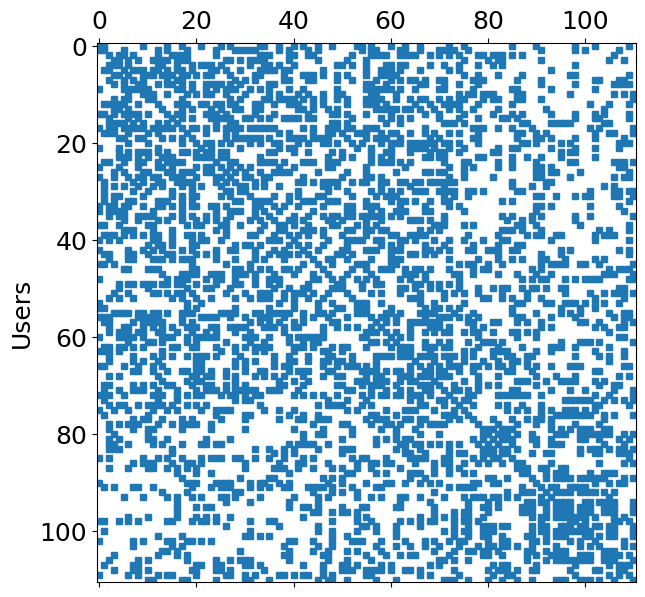

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           111 x 364 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      2.000000e-02 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=5.97e-04 nnz(S)/p=1.07e+02
* iter=1 time=2.97e-03 obj=8.02e+01 |delta(obj)|/obj=3.83e-01 nnz(X,L,W)/p=[1.07e+02 5.55e+01 1.00e+00] lns_iter=7 
* iter=2 time=5.27e-03 obj=6.56e+01 |delta(obj)|/obj=2.23e-01 nnz(X,L,W)/p=[1.07e+02 5.55e+01 1.09e+02] lns_iter=8 
* iter=3 time=4.66e-02 obj=5.19e+01 |delta(obj)|/ob

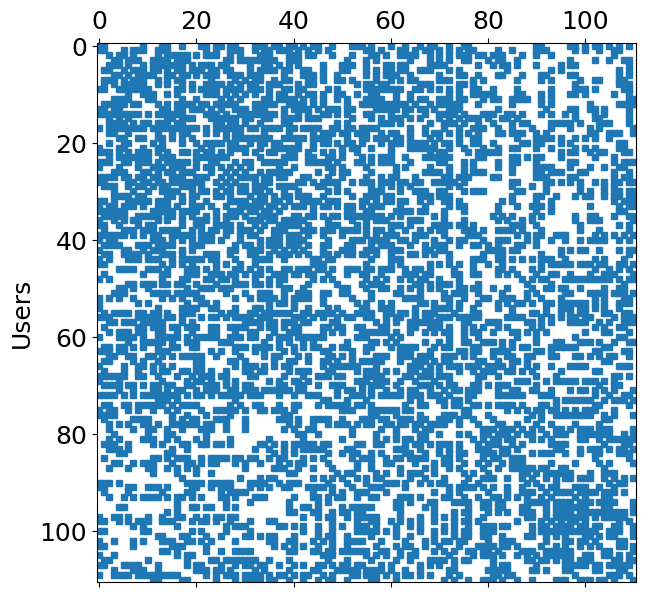

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           111 x 364 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e-02 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=5.77e-04 nnz(S)/p=1.09e+02
* iter=1 time=2.75e-03 obj=7.78e+01 |delta(obj)|/obj=4.26e-01 nnz(X,L,W)/p=[1.09e+02 5.55e+01 1.00e+00] lns_iter=7 
* iter=2 time=5.31e-03 obj=6.29e+01 |delta(obj)|/obj=2.37e-01 nnz(X,L,W)/p=[1.09e+02 5.55e+01 1.10e+02] lns_iter=8 
* iter=3 time=4.64e-02 obj=4.89e+01 |delta(obj)|/ob

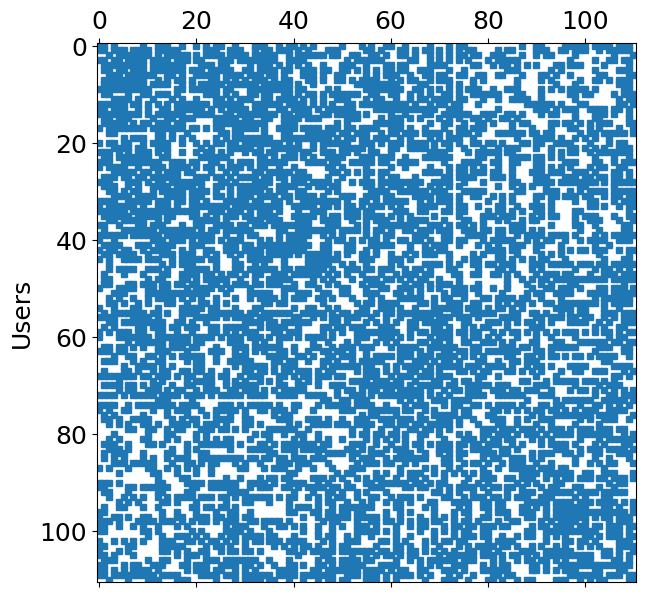

In [54]:
squic_norm_dict = {}

data_nnz = []
data_nnzr = []
data_time = []
data_sym = []

for rho in l:
    X, _, computation_time = compute_squic(Y_new, rho)
    computation_time = round(computation_time, 2)
    squic_norm_dict[rho] = X
    print(f"time required: {computation_time} seconds")

    nonz, nonz_r = count_nnz(squic_norm_dict[rho], ROWS)

    if is_symmetric(squic_norm_dict[rho]):
        print(f"✅ Matrix is symmetric per rho {rho}")
        data_sym.append('Yes')
    else:
        print(f"❌ Matrix is not symmetric per rho {rho}")
        data_sym.append('No')

    sparsity_pattern(squic_norm_dict[rho])

    data_nnz.append(nonz)
    data_nnzr.append(round(nonz_r, 2))
    data_time.append(computation_time)


table_squic_norm = [
    ["NNZ"] + data_nnz,
    ["NNZ/Row"] + data_nnzr,
    ["Time (s)"] + data_time,
    ["Symmetric"] + data_sym
]

# SQUIC-Fit

In [55]:
fit_norm_dict = {}

In [56]:
# Y = df.T.to_numpy()  # Convert to (users, days)

# # normalize the Y input data to achieve unit variance
# Y_new = np.diag(1/np.std(Y,1)) @ Y # each row of Y is scaled by the inverse of its standard deviation
# # normalizes each row so that the std dev of each user's balance over the days becomes 1

# # Y_new has shape (Users × Days).
# # S will have shape (Users × Users).

# # double check if this is correct by 
# S = np.cov(Y_new, bias=True) # "bias=true" you force cove to use n samples instead of n-1

In [57]:
# stds = np.std(Y, axis=1)
# safe_stds = np.clip(stds, 1e-8, None)  # don't allow std < 1e-8
# Y_new = np.diag(1 / safe_stds) @ Y

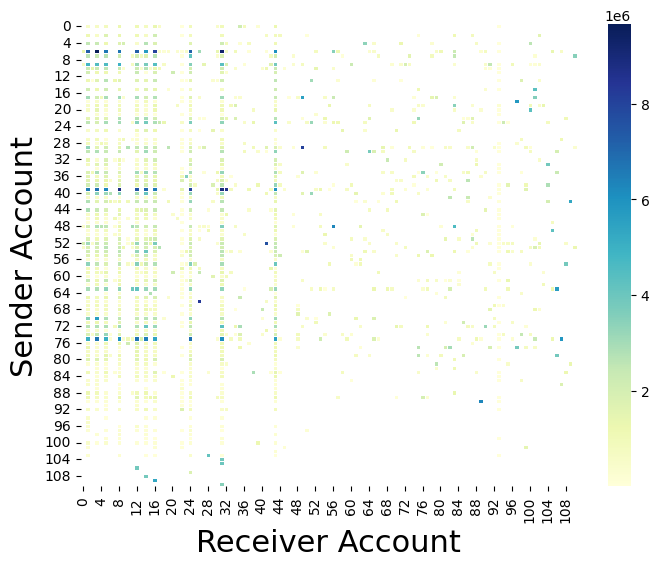

In [59]:
orig = "nameOrig"
dest = "nameDest"
amnt = "amount"  

users_list = []

transactions = pd.read_csv(DATASET)

for _, row in transactions.iterrows():
    if row[orig] not in users_list:
        users_list.append(row[orig])
    if row[dest] not in users_list:
        users_list.append(row[dest])

id_to_int = {user_id: idx for idx, user_id in enumerate(users_list)} 

rows = len(Y)

matrix = np.zeros((rows, rows))

for _, row in transactions.iterrows():
    orig_acct = int(id_to_int[row[orig]])
    bene_acct = int(id_to_int[row[dest]])
    amount = float(row[amnt])

    matrix[orig_acct][bene_acct] += amount

mask = (matrix == 0) # cover all zeros

plt.figure(figsize=(8, 6))
sns.heatmap(matrix, cmap='YlGnBu', fmt=".2f", cbar=True, mask=mask,
            linewidths=0.5, linecolor='white')

plt.xlabel("Receiver Account", fontsize=22)
plt.ylabel("Sender Account", fontsize=22)
plt.show()

In [60]:
l

[0.9, 0.5, 0.2, 0.1, 0.09, 0.05, 0.02, 0.01]


----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    2.763964e+01
 Y:         111 x 364 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.000000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* compute sample covariance matrix S: nnz(S)/p=3.36e+00 time=6.42e-04
* iter=1 time=1.38e-03 obj=1.82e+02 |delta(obj)|/obj=3.92e-01 nnz(X,L,W)/p=[3.36e+00 2.09e+00 1.52e+00] lns_iter=2 
* iter=2 time=1.68e-03 obj=1.82e+02 |delta(obj)|/obj=6.43e-06 nnz(X,L,W)/p=[3.36e+00 2.09e+00 4.62e+00] lns_iter=1 
#SQUIC Finished: time=3.99e-03 nnz(X,W)

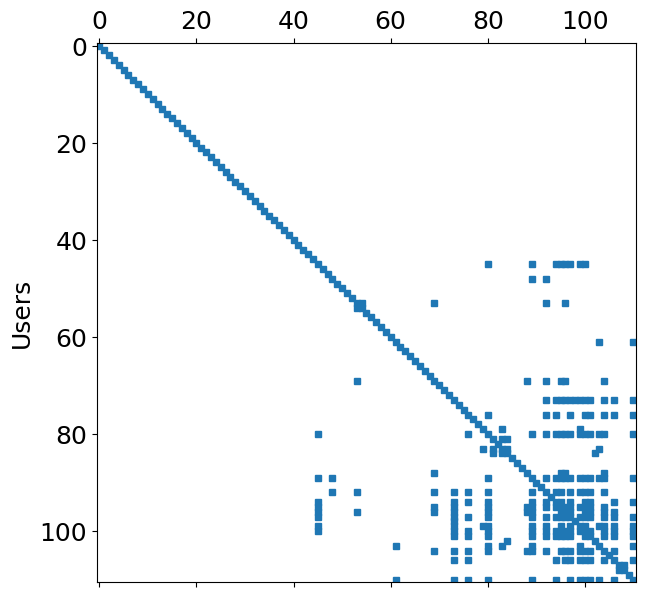


----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    2.763964e+01
 Y:         111 x 364 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      5.000000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* compute sample covariance matrix S: nnz(S)/p=2.64e+01 time=5.21e-04
* iter=1 time=1.55e-03 obj=1.56e+02 |delta(obj)|/obj=2.87e-01 nnz(X,L,W)/p=[2.64e+01 2.59e+01 1.00e+00] lns_iter=5 
* iter=2 time=2.43e-03 obj=1.54e+02 |delta(obj)|/obj=1.19e-02 nnz(X,L,W)/p=[2.64e+01 2.59e+01 3.81e+01] lns_iter=7 
* iter=3 time=6.00e-03 obj=1.49e+02 |de

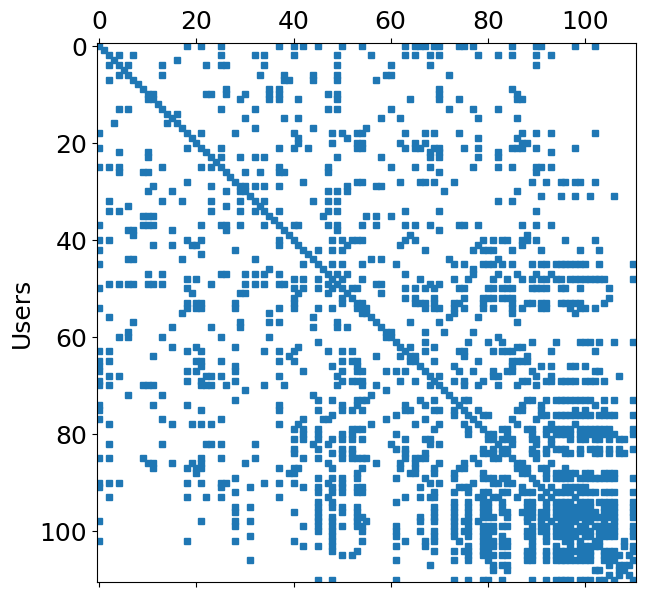


----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    2.763964e+01
 Y:         111 x 364 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      2.000000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* compute sample covariance matrix S: nnz(S)/p=5.75e+01 time=5.60e-04
* iter=1 time=2.50e-03 obj=1.08e+02 |delta(obj)|/obj=2.87e-02 nnz(X,L,W)/p=[5.75e+01 4.71e+01 1.00e+00] lns_iter=6 
* iter=2 time=4.12e-03 obj=1.03e+02 |delta(obj)|/obj=4.63e-02 nnz(X,L,W)/p=[5.75e+01 4.71e+01 1.08e+02] lns_iter=8 
* iter=3 time=1.88e-02 obj=9.54e+01 |de

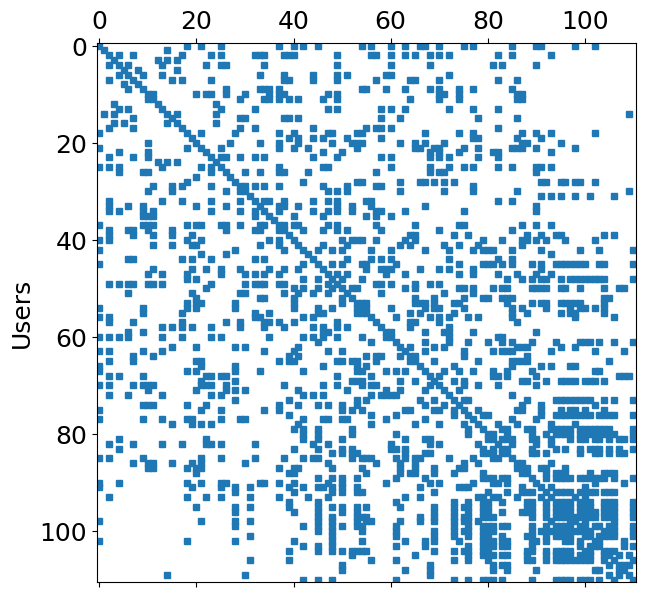


----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    2.763964e+01
 Y:         111 x 364 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* compute sample covariance matrix S: nnz(S)/p=6.95e+01 time=6.68e-04
* iter=1 time=2.36e-03 obj=8.42e+01 |delta(obj)|/obj=3.18e-01 nnz(X,L,W)/p=[6.95e+01 4.84e+01 3.07e+01] lns_iter=6 
* iter=2 time=7.34e-03 obj=7.79e+01 |delta(obj)|/obj=8.10e-02 nnz(X,L,W)/p=[6.96e+01 4.84e+01 1.10e+02] lns_iter=6 
* iter=3 time=2.96e-02 obj=6.59e+01 |de

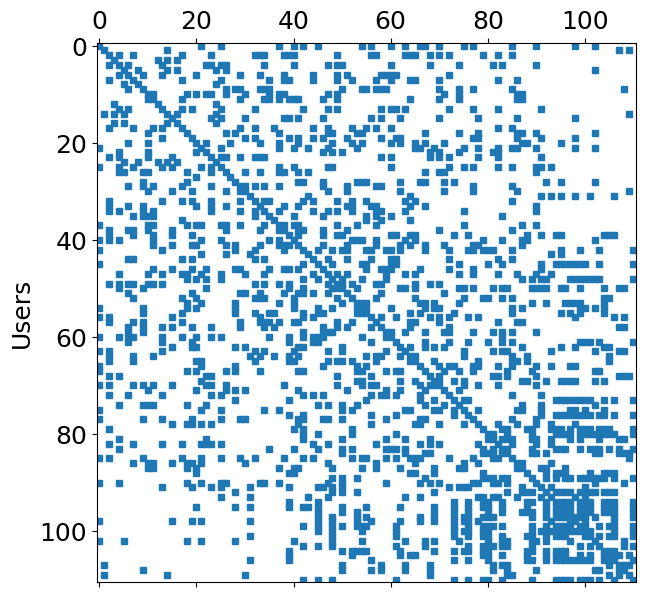


----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    2.763964e+01
 Y:         111 x 364 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.000000e-02 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* compute sample covariance matrix S: nnz(S)/p=7.10e+01 time=5.12e-04
* iter=1 time=2.25e-03 obj=8.18e+01 |delta(obj)|/obj=3.58e-01 nnz(X,L,W)/p=[7.10e+01 4.87e+01 3.83e+01] lns_iter=6 
* iter=2 time=8.17e-03 obj=7.58e+01 |delta(obj)|/obj=7.83e-02 nnz(X,L,W)/p=[7.13e+01 4.87e+01 1.10e+02] lns_iter=6 
* iter=3 time=4.58e-02 obj=6.34e+01 |de

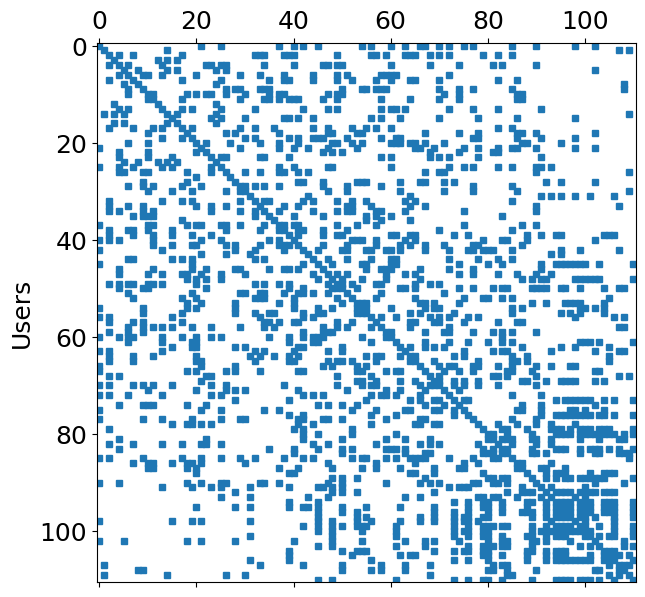


----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    2.763964e+01
 Y:         111 x 364 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      5.000000e-02 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* compute sample covariance matrix S: nnz(S)/p=7.66e+01 time=5.63e-04
* iter=1 time=2.81e-03 obj=9.25e+01 |delta(obj)|/obj=1.99e-01 nnz(X,L,W)/p=[7.66e+01 4.89e+01 1.00e+00] lns_iter=7 
* iter=2 time=4.54e-03 obj=8.12e+01 |delta(obj)|/obj=1.40e-01 nnz(X,L,W)/p=[7.66e+01 4.89e+01 9.76e+01] lns_iter=8 
* iter=3 time=2.69e-02 obj=6.50e+01 |de

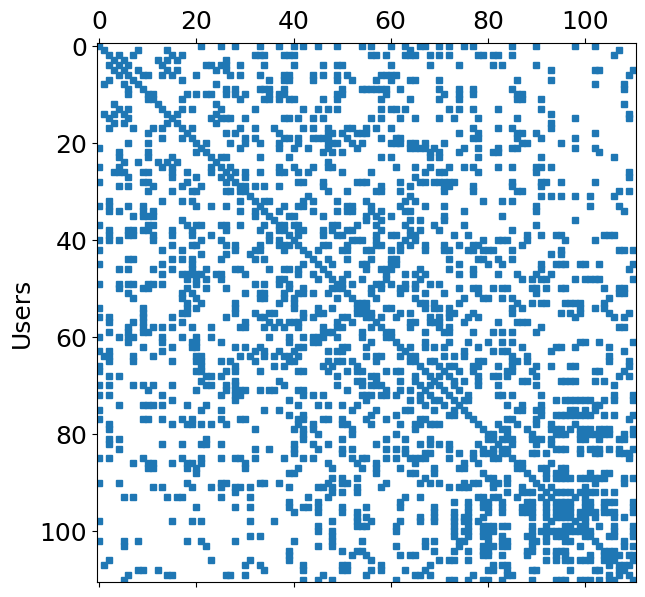


----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    2.763964e+01
 Y:         111 x 364 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      2.000000e-02 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* compute sample covariance matrix S: nnz(S)/p=8.07e+01 time=6.60e-04
* iter=1 time=2.61e-03 obj=8.63e+01 |delta(obj)|/obj=2.86e-01 nnz(X,L,W)/p=[8.07e+01 4.90e+01 1.00e+00] lns_iter=7 
* iter=2 time=4.48e-03 obj=7.37e+01 |delta(obj)|/obj=1.71e-01 nnz(X,L,W)/p=[8.07e+01 4.90e+01 9.73e+01] lns_iter=8 
* iter=3 time=2.93e-02 obj=5.61e+01 |de

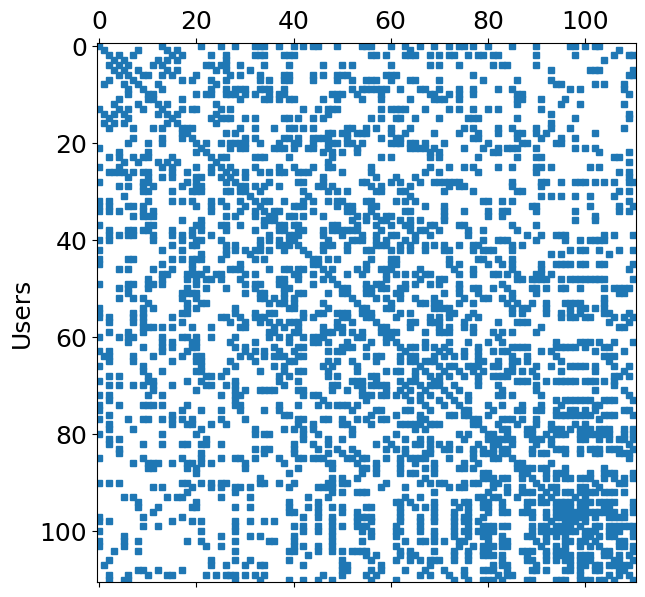


----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    2.763964e+01
 Y:         111 x 364 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e-02 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* compute sample covariance matrix S: nnz(S)/p=8.17e+01 time=5.59e-04
* iter=1 time=3.02e-03 obj=8.42e+01 |delta(obj)|/obj=3.18e-01 nnz(X,L,W)/p=[8.17e+01 4.94e+01 1.00e+00] lns_iter=7 
* iter=2 time=4.59e-03 obj=7.11e+01 |delta(obj)|/obj=1.84e-01 nnz(X,L,W)/p=[8.17e+01 4.94e+01 9.71e+01] lns_iter=8 
* iter=3 time=3.00e-02 obj=5.33e+01 |de

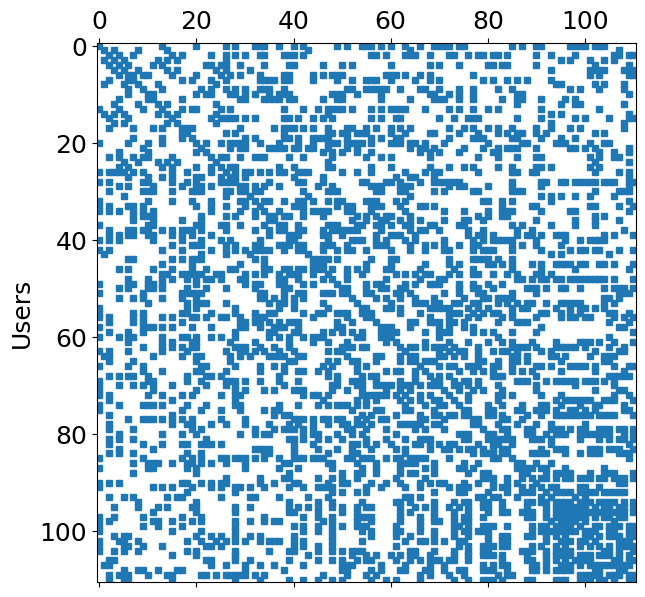

In [61]:
data_nnz = []
data_nnzr = []
data_time = []
data_sym = []

for rho in l:
    fit_norm_dict[rho], end_time = squic_fit_matrix(Y=Y_new, l=rho, matrix=matrix)
    end_time = round(end_time, 2)
    print(f"required time: {end_time}")
    
    nnz, nnz_r = nnz_fit(fit_norm_dict[rho], ROWS)
    print(f"nnz = {nnz} per rows = {nnz_r}")

    if is_symmetric(fit_norm_dict[rho]):
        print(f"✅ Matrix is symmetric per rho {rho}")
        data_sym.append('Yes')
    else:
        print(f"❌ Matrix is not symmetric per rho {rho}")
        data_sym.append('No')

    sparsity_pattern(fit_norm_dict[rho])

    data_nnz.append(nnz)
    data_nnzr.append(round(nnz_r, 2))
    data_time.append(end_time)

table_fit = [
    ["NNZ"] + data_nnz,
    ["NNZ/Row"] + data_nnzr,
    ["Time (s)"] + data_time,
    ["Symmetric"] + data_sym
]

# Table

In [62]:
def table(data, title, l):
    table = tabulate(
        data,
        headers=[title] + l,
        tablefmt="fancy_grid",
        numalign="center",
        stralign="center"
    )
    return table

In [63]:
print(table(table_squic_norm, "SQUIC NORM", l))

print(table(table_fit, "SQUIC FIT NORM", l))

╒══════════════╤═══════╤═══════╤═══════╤═══════╤════════╤════════╤════════╤════════╕
│  SQUIC NORM  │  0.9  │  0.5  │  0.2  │  0.1  │  0.09  │  0.05  │  0.02  │  0.01  │
╞══════════════╪═══════╪═══════╪═══════╪═══════╪════════╪════════╪════════╪════════╡
│     NNZ      │  363  │ 1871  │ 2415  │ 2873  │  2975  │  3619  │  5015  │  6243  │
├──────────────┼───────┼───────┼───────┼───────┼────────┼────────┼────────┼────────┤
│   NNZ/Row    │ 3.27  │ 16.86 │ 21.76 │ 25.88 │  26.8  │  32.6  │ 45.18  │ 56.24  │
├──────────────┼───────┼───────┼───────┼───────┼────────┼────────┼────────┼────────┤
│   Time (s)   │  0.0  │ 0.07  │ 0.17  │ 0.56  │  0.67  │  1.55  │  3.4   │  7.29  │
├──────────────┼───────┼───────┼───────┼───────┼────────┼────────┼────────┼────────┤
│  Symmetric   │  Yes  │  Yes  │  Yes  │  Yes  │  Yes   │  Yes   │  Yes   │  Yes   │
╘══════════════╧═══════╧═══════╧═══════╧═══════╧════════╧════════╧════════╧════════╛
╒══════════════════╤═══════╤═══════╤═══════╤═══════╤════════╤════